20.602041703090325
20.684
A condição de estabilidade foi satisfeita.
lambda = 0.495138157616275


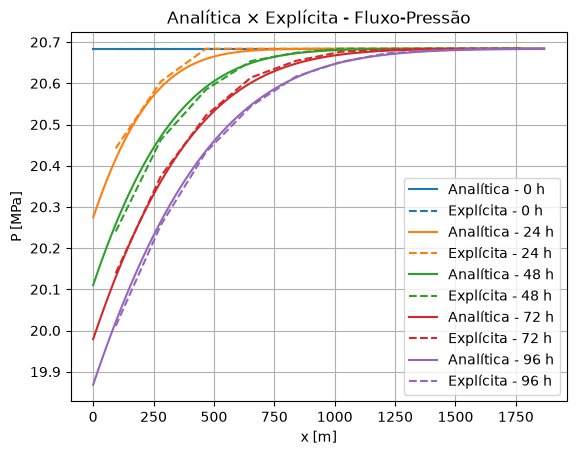

A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.
A condição de estabilidade foi satisfeita.


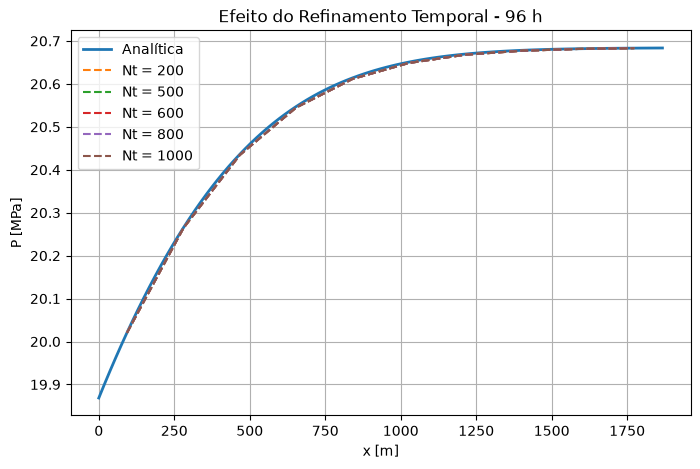

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from analytical.transiente_L1d_FP import linear_trans_1d_FP
from mdf.explicita import explicita_1d_FP

p0 = 20.684e6
Pe = p0

A_R = 3484800
L = np.sqrt(A_R)

qw = 4.968e-3

k = 339 * 9.869233e-16
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

h = 4.572
largura = L
A = h * largura

t_h = 96 #horas
t_final = t_h * 3600

eta = k / (phi * ct * mu)

#aolução analítica
x_an, t_an, X, T, P_an = linear_trans_1d_FP(
    p0, qw, L, k, A, mu, eta, t_final
)

#solução explicita
nx = 10
nt = 10

x_exp, t_exp, P_exp, lambd = explicita_1d_FP(
    p0,
    Pe,
    -qw,       # fluxo de produção na esquerda
    h,
    L,
    largura,
    k,
    phi,
    ct,
    mu,
    t_final,
    nx,
    nt
)

print("lambda =", lambd)

tempos_escolhidos = np.linspace(0, t_h, 5)

#gráfico de comparação entre as soluções analítica e explícita

for tempo in tempos_escolhidos:
    i_an = np.argmin(np.abs(t_an - tempo*3600))
    i_exp = np.argmin(np.abs(t_exp - tempo*3600))

    linha, = plt.plot(
        x_an, P_an[i_an, :]/1e6,
        label=f'Analítica - {tempo:.0f} h'
    )

    plt.plot(
        x_exp, P_exp[i_exp, :]/1e6, '--',
        color=linha.get_color(),
        label=f'Explícita - {tempo:.0f} h'
    )

plt.xlabel('x [m]')
plt.ylabel('P [MPa]')
plt.title('Analítica × Explícita - Fluxo-Pressão')
plt.legend()
plt.grid()
plt.show()

# comparação da solução explícita com diferentes refinamentos temporais

nx = 10

nt_values = [200,500,600,800,1000]

tempo = 96
t_escolhido = tempo * 3600

i_an = np.argmin(
    np.abs(t_an - t_escolhido)
)


# solução analítica

plt.figure(figsize=(8, 5))

plt.plot(
    x_an,
    P_an[i_an, :] / 1e6,
    linewidth=2,
    label="Analítica"
)


# soluções explícitas para diferentes Nt

for nt_i in nt_values:

    x_i, t_i, P_i, lambd_i = explicita_1d_FP(
        p0,
        Pe,
        -qw,
        h,
        L,
        largura,
        k,
        phi,
        ct,
        mu,
        t_final,
        nx,
        nt_i
    )

    i_exp = np.argmin(
        np.abs(t_i - t_escolhido)
    )

    plt.plot(
        x_i,
        P_i[i_exp, :] / 1e6,
        "--",
        label=f"Nt = {nt_i}"
    )


plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Efeito do Refinamento Temporal - 96 h")

plt.legend()
plt.grid()
plt.show()